### Dataset
I used the Fashion-MNIST dataset:
https://github.com/zalandoresearch/fashion-mnist

This dataset consists of 60,000 training images and 10,000 test images of grayscale clothing items across 10 classes.


### Model Architecture
I implemented a CNN consisting of:

- Two convolutional layers:
  - Conv1: 32 filters, kernel size 3x3
  - Conv2: 64 filters, kernel size 3x3
- Each convolution layer is followed by ReLU activation and MaxPooling
- A fully connected layer with 128 neurons
- Dropout (0.3) to reduce overfitting
- Final output layer with 10 classes

The input images are small (28x28), so a shallow architecture is sufficient.

- The first convolutional layer captures low-level features such as edges.
- The second convolutional layer captures higher-level patterns like clothing shapes.
- MaxPooling reduces spatial dimensions and computation.
- The fully connected layer enables learning complex class relationships.
- Dropout helps prevent overfitting.


### Training Details
- Loss Function: CrossEntropyLoss
- Optimizer: Adam (learning rate = 0.001)
- Batch Size: 64
- Epochs: 5


In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True


In [2]:
from torchvision import datasets, transforms

# Transform: convert to tensor + normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.7MB/s]

Train size: 60000
Test size: 10000


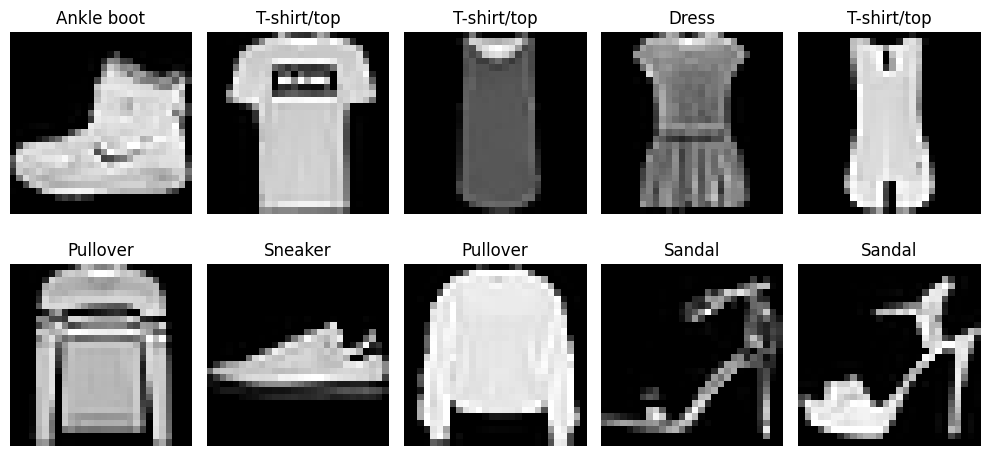

In [3]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    image = image.squeeze().numpy()

    ax.imshow(image, cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 938
Number of test batches: 157


In [5]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)   
print("Label batch shape:", labels.shape)  

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Convolutional base
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dense classifier
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   
        x = self.pool(F.relu(self.conv2(x))) 
        x = torch.flatten(x, 1)               
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

Using device: cuda
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_accuracies.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    return train_losses, test_accuracies

In [9]:
train_losses, test_accuracies = train_model(
    model, train_loader, test_loader, criterion, optimizer, device, epochs=5
)

Epoch [1/5], Train Loss: 0.4750, Test Accuracy: 87.99%
Epoch [2/5], Train Loss: 0.3055, Test Accuracy: 89.73%
Epoch [3/5], Train Loss: 0.2562, Test Accuracy: 91.01%
Epoch [4/5], Train Loss: 0.2250, Test Accuracy: 90.73%
Epoch [5/5], Train Loss: 0.2005, Test Accuracy: 91.43%


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.92      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.83      0.86      1000
       Dress       0.91      0.94      0.92      1000
        Coat       0.80      0.92      0.86      1000
      Sandal       1.00      0.96      0.98      1000
       Shirt       0.81      0.66      0.73      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



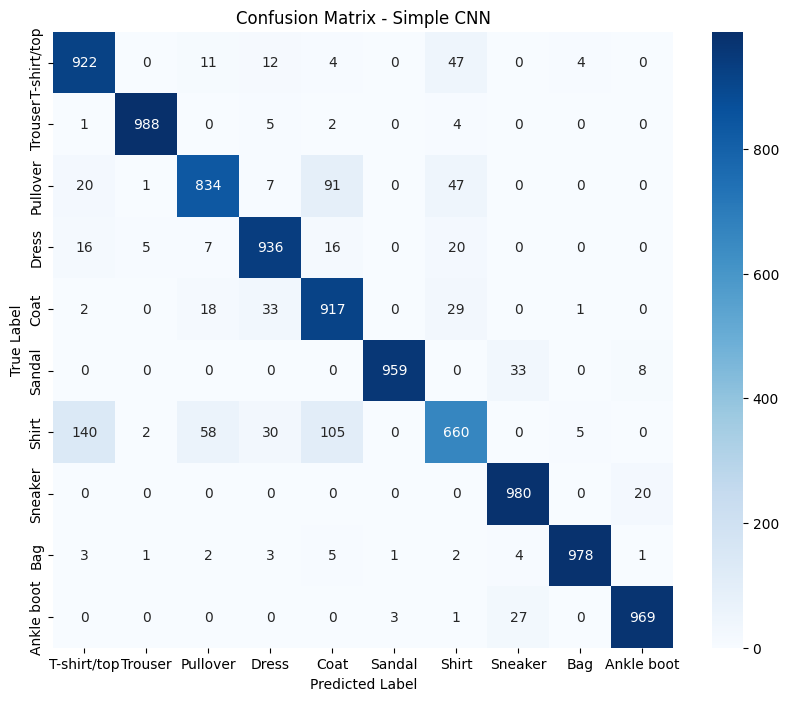

In [11]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple CNN")
plt.show()

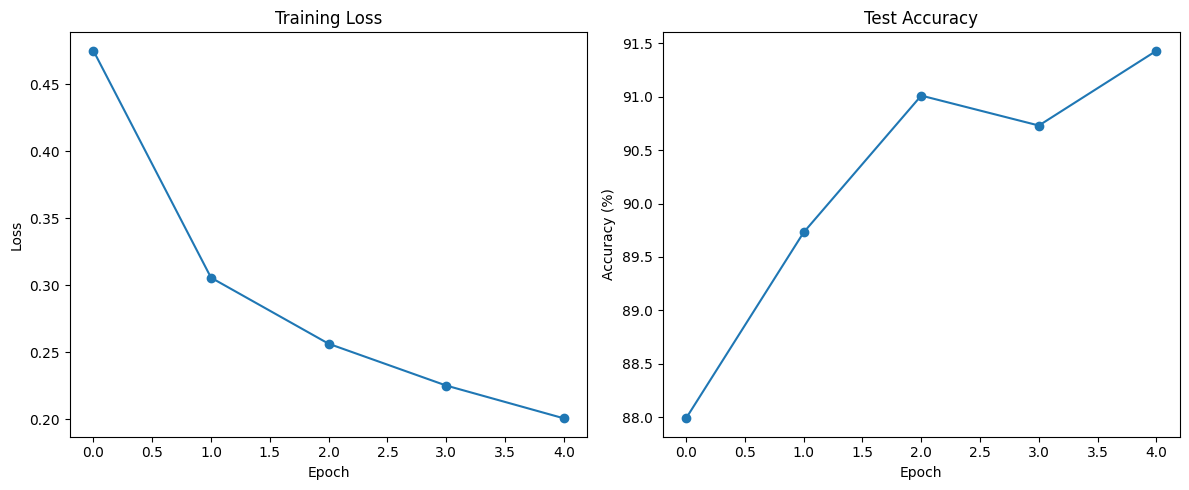

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, marker='o')
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


### Results
Final Test Accuracy: 91.43%

#### Classification Report Summary:
- High performance on classes like Trouser, Sandal, Sneaker, Bag, and Ankle boot (≥96%)
- Lower performance on visually similar classes like Shirt and T-shirt/top

### Observations
- The model performs well overall, achieving over 91% accuracy.
- Confusion occurs mainly between similar clothing categories (Shirt vs T-shirt/top, Pullover vs Coat)
- The training loss steadily decreases, indicating stable learning.
- Test accuracy improves consistently, suggesting no major overfitting.

## Part 2: Transfer Learning with MobileNetV2

For transfer learning, I used MobileNetV2, which is a lightweight pretrained convolutional neural network originally trained on ImageNet. Since Fashion-MNIST images are grayscale and small (28x28), I resized them to 224x224 and converted them to 3 channels so they could be processed by MobileNetV2.

I froze the pretrained feature extraction layers and replaced the final classification layer with a new linear layer for the 10 Fashion-MNIST classes.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform_transfer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dataset_t = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_transfer
)

test_dataset_t = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_transfer
)

# smaller subset for faster transfer learning
train_subset = Subset(train_dataset_t, list(range(15000)))
test_subset = Subset(test_dataset_t, list(range(3000)))

train_loader_t = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader_t = DataLoader(test_subset, batch_size=64, shuffle=False)

weights = MobileNet_V2_Weights.DEFAULT
model_t = mobilenet_v2(weights=weights)

for param in model_t.features.parameters():
    param.requires_grad = False

model_t.classifier[1] = nn.Linear(model_t.last_channel, 10)
model_t = model_t.to(device)

criterion_t = nn.CrossEntropyLoss()
optimizer_t = torch.optim.Adam(model_t.classifier.parameters(), lr=0.001)

print("Transfer model ready")

Using device: cuda
Transfer model ready


In [18]:
def train_transfer_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=2):
    train_losses_t = []
    test_accuracies_t = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses_t.append(avg_train_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_accuracies_t.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    return train_losses_t, test_accuracies_t

In [19]:
train_losses_t, test_accuracies_t = train_transfer_model(
    model_t, train_loader_t, test_loader_t, criterion_t, optimizer_t, device, epochs=2
)

Epoch [1/2], Train Loss: 1.0689, Test Accuracy: 78.63%
Epoch [2/2], Train Loss: 0.6614, Test Accuracy: 81.33%


In [20]:
from sklearn.metrics import classification_report

model_t.eval()
all_preds_t = []
all_labels_t = []

with torch.no_grad():
    for images, labels in test_loader_t:
        images, labels = images.to(device), labels.to(device)
        outputs = model_t(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_t.extend(predicted.cpu().numpy())
        all_labels_t.extend(labels.cpu().numpy())

print("Classification Report (Transfer Learning):\n")
print(classification_report(all_labels_t, all_preds_t, target_names=classes))

Classification Report (Transfer Learning):

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.75      0.76       302
     Trouser       0.98      0.93      0.95       308
    Pullover       0.79      0.72      0.75       310
       Dress       0.77      0.84      0.80       298
        Coat       0.72      0.65      0.69       324
      Sandal       0.95      0.89      0.92       285
       Shirt       0.52      0.60      0.56       298
     Sneaker       0.88      0.93      0.91       293
         Bag       0.91      0.94      0.92       297
  Ankle boot       0.92      0.91      0.91       285

    accuracy                           0.81      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.81      0.81      3000



### Transfer Learning Results
Final Test Accuracy (MobileNetV2): 80.93%

#### Classification Report Summary:
- Strong performance on classes such as Trouser (95% F1), Sneaker (90%), Bag (93%), and Ankle boot (91%)
- Moderate performance on Dress and Sandal
- Lower performance on visually similar upper-body clothing items such as Shirt (55%) and T-shirt/top (74%)


### Comparison with Custom CNN
- Custom CNN Accuracy: 91.43%
- MobileNetV2 Accuracy: 80.93%

### Observations

The custom CNN significantly outperformed the pretrained MobileNetV2 model on this task. Several factors can explain this result:

1. **Dataset Characteristics**
   - Fashion-MNIST is a simple, low-resolution grayscale dataset.
   - A small, task-specific CNN is sufficient to learn meaningful features.

2. **Domain Mismatch**
   - MobileNetV2 was pretrained on ImageNet, which consists of high-resolution RGB images.
   - The structural differences between ImageNet and Fashion-MNIST reduce the effectiveness of transferred features.

3. **Input Transformation Effects**
   - Images were resized from 28×28 to 224×224 and converted to 3 channels.
   - This does not introduce new information and may degrade feature quality.

4. **Subset Training**
   - A smaller subset of the dataset was used for faster training.
   - This may slightly reduce performance compared to using the full dataset.


### Class-Level Insights

- The model performs well on distinct categories like footwear and accessories.
- Confusion is highest among similar categories such as:
  - Shirt vs T-shirt/top
  - Pullover vs Coat

This indicates that pretrained features are less effective at distinguishing subtle differences in simple grayscale images.


### Conclusion

Transfer learning did not outperform the custom CNN in this case. This demonstrates that pretrained models are not always optimal, especially when the dataset is small, low-resolution, or significantly different from the data used during pretraining.

## Part 3: Data Augmentation

In this part, I used data augmentation to increase the diversity of the training data. Data augmentation helps improve generalization by exposing the model to modified versions of the same images during training.

For this experiment, I applied:
- random rotation
- random horizontal flipping

I then retrained the same CNN architecture from Part 1.

In [21]:
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_aug = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_aug
)

test_dataset_aug = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=64, shuffle=False)

print("Augmented dataset ready")
print("Train size:", len(train_dataset_aug))
print("Test size:", len(test_dataset_aug))

Augmented dataset ready
Train size: 60000
Test size: 10000


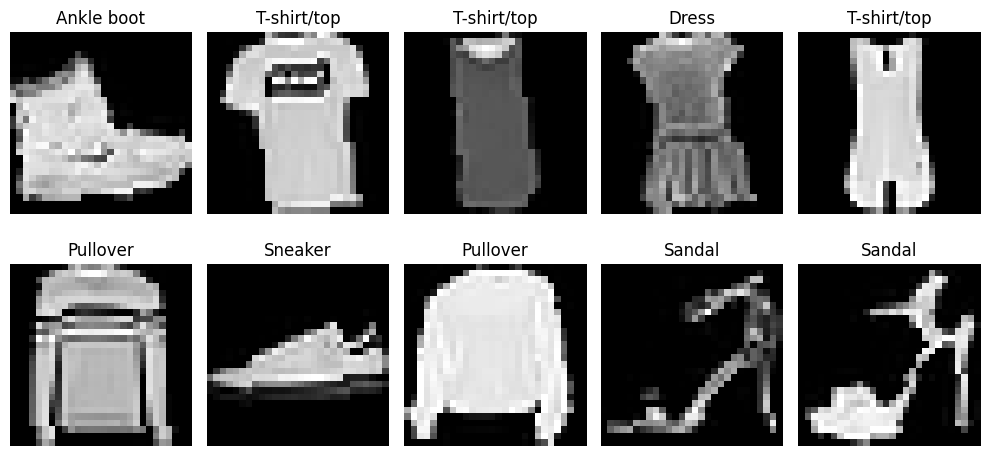

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset_aug[i]
    image = image.squeeze().numpy()
    ax.imshow(image, cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [23]:
model_aug = SimpleCNN().to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

print("Augmentation model ready on", device)

Augmentation model ready on cuda


In [24]:
train_losses_aug, test_accuracies_aug = train_model(
    model_aug,
    train_loader_aug,
    test_loader_aug,
    criterion_aug,
    optimizer_aug,
    device,
    epochs=5
)

Epoch [1/5], Train Loss: 0.5663, Test Accuracy: 86.34%
Epoch [2/5], Train Loss: 0.3903, Test Accuracy: 88.25%
Epoch [3/5], Train Loss: 0.3413, Test Accuracy: 89.44%
Epoch [4/5], Train Loss: 0.3083, Test Accuracy: 89.88%
Epoch [5/5], Train Loss: 0.2904, Test Accuracy: 90.77%


In [ ]:
from sklearn.metrics import classification_report

model_aug.eval()
all_preds_aug = []
all_labels_aug = []

with torch.no_grad():
    for images, labels in test_loader_aug:
        images, labels = images.to(device), labels.to(device)
        outputs = model_aug(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_aug.extend(predicted.cpu().numpy())
        all_labels_aug.extend(labels.cpu().numpy())

print("Classification Report (Augmented Model):\n")
print(classification_report(all_labels_aug, all_preds_aug, target_names=classes))

## Part 3: Results and Analysis (Data Augmentation)

### Results
Final Test Accuracy (Augmented CNN): 90.77%

### Comparison with Baseline CNN
- Baseline CNN Accuracy: 91.43%
- Augmented CNN Accuracy: 90.77%

### Observations

Data augmentation did not improve performance in this case and resulted in a slightly lower accuracy. This can be explained by:

1. **Dataset Simplicity**
   - Fashion-MNIST is a relatively simple dataset.
   - The baseline model was already able to generalize well without additional data variation.

2. **Limited Augmentation Types**
   - Only small rotations and horizontal flips were applied.
   - These transformations may not significantly enrich the dataset.

3. **Potential Information Distortion**
   - Some augmentations (e.g., flipping clothing items) may produce unrealistic variations.
   - This can introduce noise rather than useful learning signals.

4. **Training Time**
   - With only 5 epochs, the model may not fully benefit from augmented data.

### Conclusion

Data augmentation did not provide a noticeable improvement for this task. However, in more complex datasets, augmentation is often essential for improving generalization and preventing overfitting.